In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Finance_Loan_Default_Dataset.csv')
df

,Customer_ID,Age,Monthly_Income,Loan_Amount,Loan_Type,Credit_Score,Loan_Status
0,C1001,21,62824,170659,Personal,643,Default
1,C1002,57,126944,856617,Business,412,Paid
2,C1003,37,36875,1370393,Vehicle,856,Paid
3,C1004,44,46528,2842731,Vehicle,582,Default
4,C1005,53,128824,433280,Vehicle,366,Default
...,...,...,...,...,...,...,...
995,C1996,48,132393,2466875,Vehicle,487,Default
996,C1997,22,50615,1105096,Business,408,Default
997,C1998,42,84847,1244232,Personal,362,Default
998,C1999,21,34896,2852129,Business,390,Default


In [4]:
df.head()

,Customer_ID,Age,Monthly_Income,Loan_Amount,Loan_Type,Credit_Score,Loan_Status
0,C1001,21,62824,170659,Personal,643,Default
1,C1002,57,126944,856617,Business,412,Paid
2,C1003,37,36875,1370393,Vehicle,856,Paid
3,C1004,44,46528,2842731,Vehicle,582,Default
4,C1005,53,128824,433280,Vehicle,366,Default


In [5]:
df.info

<bound method DataFrame.info of     Customer_ID  Age  Monthly_Income  Loan_Amount Loan_Type  Credit_Score  \
0         C1001   21           62824       170659  Personal           643   
1         C1002   57          126944       856617  Business           412   
2         C1003   37           36875      1370393   Vehicle           856   
3         C1004   44           46528      2842731   Vehicle           582   
4         C1005   53          128824       433280   Vehicle           366   
..          ...  ...             ...          ...       ...           ...   
995       C1996   48          132393      2466875   Vehicle           487   
996       C1997   22           50615      1105096  Business           408   
997       C1998   42           84847      1244232  Personal           362   
998       C1999   21           34896      2852129  Business           390   
999       C2000   23          110255       191263   Vehicle           394   

    Loan_Status  
0       Default  
1      

In [6]:
df.dtypes

Customer_ID       object
Age                int64
Monthly_Income     int64
Loan_Amount        int64
Loan_Type         object
Credit_Score       int64
Loan_Status       object
dtype: object

In [7]:
df.shape

(1000, 7)

In [8]:
df.isnull().sum()

Customer_ID       0
Age               0
Monthly_Income    0
Loan_Amount       0
Loan_Type         0
Credit_Score      0
Loan_Status       0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.describe()

,Age,Monthly_Income,Loan_Amount,Credit_Score
count,1000.000000,1000.0000,1.000000e+03,1000.000000
mean,39.708000,87422.8410,1.530303e+06,606.900000
std,11.632371,38681.0363,8.645264e+05,167.922172
min,21.000000,20263.0000,5.012400e+04,301.000000
25%,29.000000,52987.2500,7.674550e+05,455.750000
50%,40.000000,90212.0000,1.559480e+06,620.000000
75%,50.000000,121846.5000,2.277797e+06,747.000000
max,60.000000,149878.0000,2.998930e+06,900.000000


In [12]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Age'] < Q1 - 1.5*IQR)|(df['Age'] > Q3 + 1.5*IQR)]
print(outliers)

Empty DataFrame
Columns: [Customer_ID, Age, Monthly_Income, Loan_Amount, Loan_Type, Credit_Score, Loan_Status]
Index: []


# Problems

In [32]:
#Problem 1
total_customers = len(df)
print("Total Customers:", total_customers)

Total Customers: 1000


In [33]:
#Problem 2
default_customers = df[df['Loan_Status'] == 'Default'].shape[0]
default_percentage = (default_customers / len(df)) * 100
print("Default Percentage:", default_percentage)

Default Percentage: 40.1


In [34]:
#Problem 3
avg_income = df['Monthly_Income'].mean()
print("Average Income:", avg_income)

Average Income: 87422.841


In [46]:
#Problem 4
bins = [18,30,40,50,60,100]
labels = ['18-30','31-40','41-50','51-60','60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_defaults = df[df['Loan_Status']=='Default'].groupby('Age_Group').size()
print(age_defaults)
print("\nHighest Risk Age Group:")
print(age_defaults.idxmax())

Age_Group
18-30    112
31-40     94
41-50    109
51-60     86
60+        0
dtype: int64

Highest Risk Age Group:
18-30


C:\Users\kavya\AppData\Local\Temp\ipykernel_14488\1899840539.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_defaults = df[df['Loan_Status']=='Default'].groupby('Age_Group').size()


In [45]:
#Problem 5
loan_defaults = df[df['Loan_Status']=='Default'].groupby('Loan_Type').size()
print(loan_defaults)
print("\nHighest Risk Loan Type:")
print(loan_defaults.idxmax())

Loan_Type
Business    122
Home         91
Personal     85
Vehicle     103
dtype: int64

Highest Risk Loan Type:
Business


In [50]:
#Problem 6
paid_credit_score = df[df['Loan_Status']=='Paid']['Credit_Score'].mean()
print("Average Credit Score of Paid Customers:", round(paid_credit_score,2))

Average Credit Score of Paid Customers: 673.12


In [57]:
#Problem 7
default_credit_score = df[df['Loan_Status']=='Default']['Credit_Score'].mean()
print("Average Credit Score of Default Customers:", round(default_credit_score,2))

Average Credit Score of Default Customers: 507.99


In [60]:
#Problem 9
correlation = df['Monthly_Income'].corr(df['Credit_Score'])
print("Correlation =", round(correlation, 3))

Correlation = -0.018


# Graphs

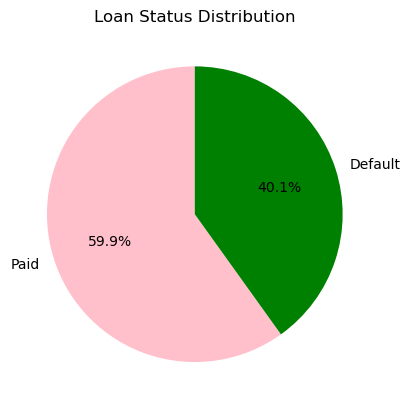

In [69]:
# Graph 1
loan_status = df['Loan_Status'].value_counts()
plt.pie(loan_status, labels=loan_status.index, autopct='%1.1f%%', startangle=90, colors=['pink', 'green'])
plt.title("Loan Status Distribution")
plt.show()

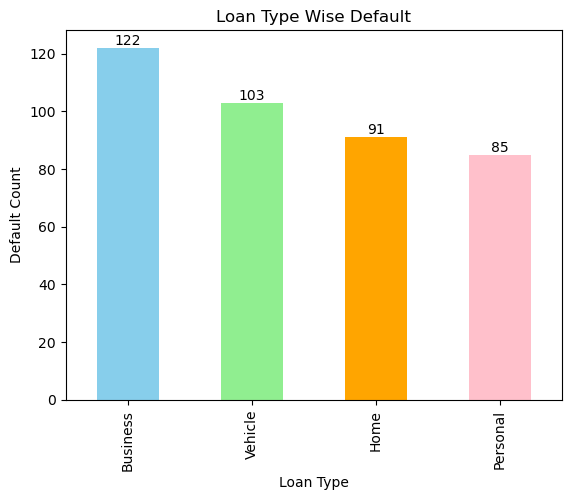

In [82]:
# Graph 2
loan_type_count = df[df['Loan_Status'] == 'Default']['Loan_Type'].value_counts()
ax = loan_type_count.plot(kind='bar',color=['skyblue','lightgreen','orange','pink'])
plt.title("Loan Type Wise Default")
plt.xlabel("Loan Type")
plt.ylabel("Default Count")
for i in ax.containers:
    ax.bar_label(i)
plt.show()

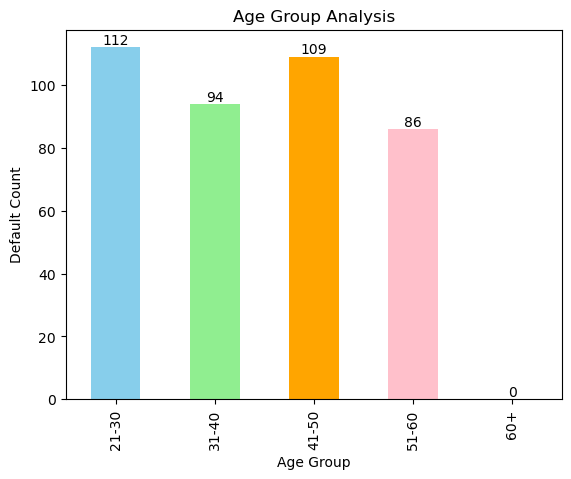

In [87]:
# Graph 3
default_age = df[df['Loan_Status'] == 'Default']['Age_Group'].value_counts().sort_index()
ax = default_age.plot(kind='bar', color=['skyblue','lightgreen','orange','pink','red'])
plt.title("Age Group Analysis")
plt.xlabel("Age Group")
plt.ylabel("Default Count")
for i in ax.containers:
    ax.bar_label(i)
plt.show()

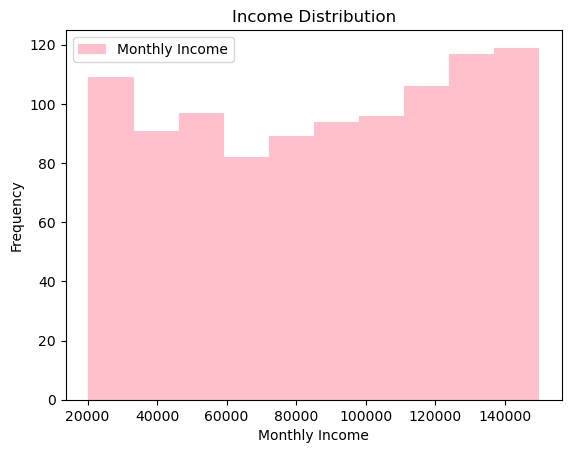

In [97]:
# Graph 4
plt.hist(df['Monthly_Income'], bins=10, label='Monthly Income', color='pink')
plt.title("Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.legend()
plt.show()

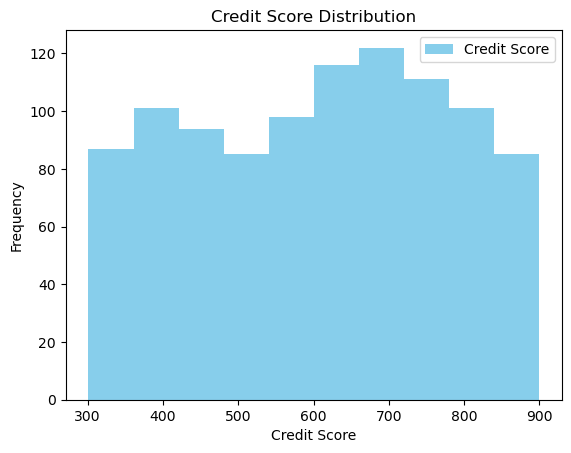

In [95]:
# Graph 5
plt.hist(df['Credit_Score'], bins=10, label='Credit Score', color='skyblue')
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

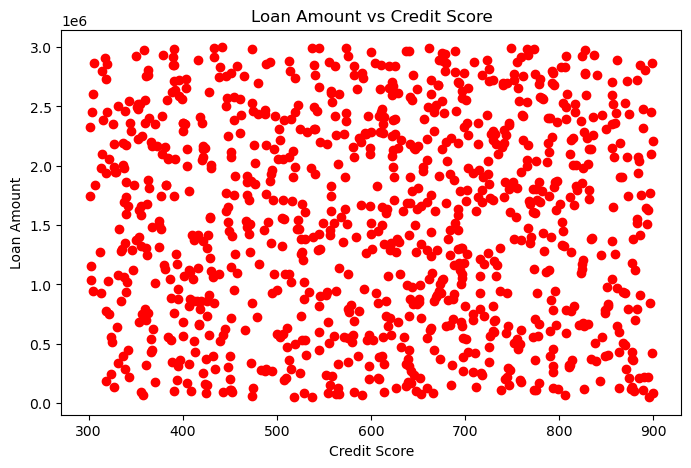

In [109]:
# Graph 6
plt.figure(figsize=(8,5))
plt.scatter(df["Credit_Score"], df["Loan_Amount"] , color='red')
plt.title("Loan Amount vs Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.show()

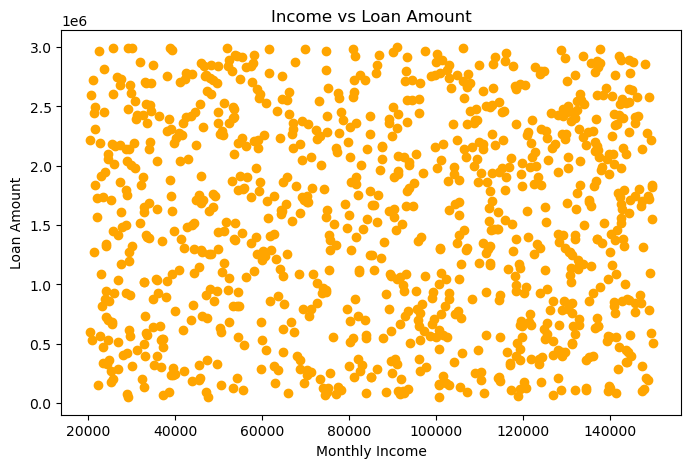

In [111]:
# Graph 7
plt.figure(figsize=(8,5))
plt.scatter(df["Monthly_Income"], df["Loan_Amount"], color='orange')
plt.title("Income vs Loan Amount")
plt.xlabel("Monthly Income")
plt.ylabel("Loan Amount")
plt.show()

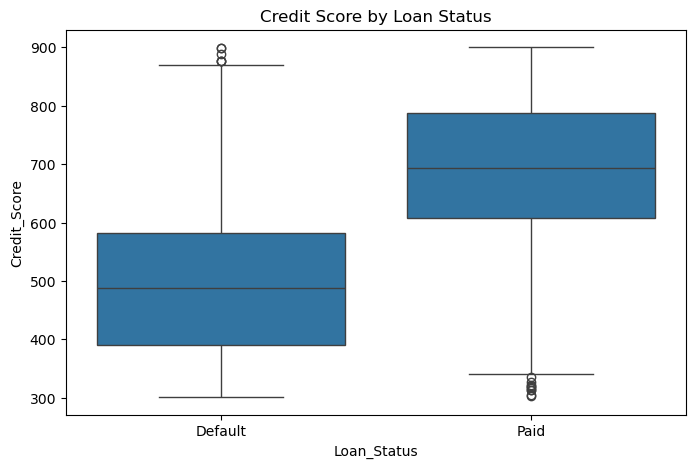

In [119]:
# Graph 8
plt.figure(figsize=(8,5))
sns.boxplot(x="Loan_Status", y="Credit_Score", data=df)
plt.title("Credit Score by Loan Status")
plt.show()

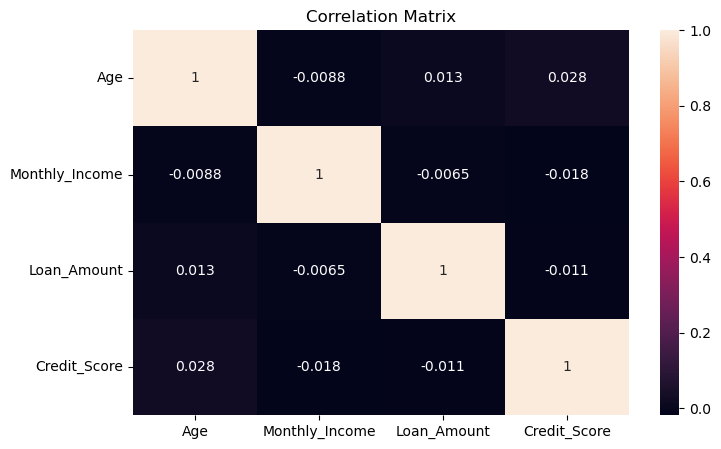

In [124]:
# Graph 9
corr = df[["Age","Monthly_Income","Loan_Amount","Credit_Score"]].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()